In [1]:
import re
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Sample config text
config_text = """
INFO     -   65   -     MultiMAE     - 2024-02-04 12:12:39,219 - run debug-only-semseg_2024-02-04_12:12:35 started
WARNING  -   65   -     MultiMAE     - 2024-02-04 12:12:39,221 - `iters_per_epoch` was not passed to the constructor. Defaulting to the length of the dataloader.
INFO     -   65   -     MultiMAE     - 2024-02-04 12:12:39,221 - Epoch 0001: train started
INFO     -   65   -     MultiMAE     - 2024-02-04 14:03:20,022 - Epoch 0001: avg train loss = 1585
INFO     -   65   -     MultiMAE     - 2024-02-04 14:03:20,022 - Epoch 0001: train finished
INFO     -   65   -     MultiMAE     - 2024-02-04 14:03:20,033 - Epoch 0001: validation started
INFO     -   65   -     MultiMAE     - 2024-02-04 14:12:02,099 - Epoch 0001: validation metrics: {'rmse': 795.7082681776602, 'rel': 0.025815852057141594, 'srel': 27.80106708671473, 'log10': 0.03658892454791673, 'delta_1': 0.999663034571877, 'delta_2': 0.999980092048645, 'delta_3': 1.0}
INFO     -   65   -     MultiMAE     - 2024-02-04 14:12:02,100 - Epoch 0001: validation finished
INFO     -   65   -     MultiMAE     - 2024-02-04 14:12:02,101 - Epoch: 1; metrics on val: {'rmse': 795.7082681776602, 'rel': 0.025815852057141594, 'srel': 27.80106708671473, 'log10': 0.03658892454791673, 'delta_1': 0.999663034571877, 'delta_2': 0.999980092048645, 'delta_3': 1.0}
INFO     -   65   -     MultiMAE     - 2024-02-04 14:12:03,731 - Epoch 0002:
"""
# Extracting loss values
#train_loss_pattern = r"Epoch (\d{4}): avg train loss = (\d+)"
#Epoch 0025: validation metrics: {
train_loss_pattern = r"Epoch: (\d+); metrics on train: {'berhu_loss': ([\d.]+), 'rmse': ([\d.]+)"
val_loss_pattern = r"Epoch (\d{4}): validation metrics: {'berhu_loss': ([\d.]+), 'rmse': ([\d.]+)"

In [3]:
with open('/home/MultiModalCoreset/multimae/zh_logs/rgb-augmented_2024-03-08_11:10:18.log', 'r') as f:
    rgb_text = ''.join(f.readlines())

with open('/home/MultiModalCoreset/multimae/zh_logs/semseg-augmented_2024-03-09_16:58:23.log', 'r') as f:
    semseg_text = ''.join(f.readlines())

with open('/home/MultiModalCoreset/multimae/zh_logs/rgb-semseg-augmented_2024-03-07_15:41:00.log', 'r') as f:
    multi_text = ''.join(f.readlines())

In [4]:
# Find all matches
train_losses_rgb = re.findall(train_loss_pattern, rgb_text)
val_losses_rgb = re.findall(val_loss_pattern, rgb_text)

train_losses_semseg = re.findall(train_loss_pattern, semseg_text)
val_losses_semseg = re.findall(val_loss_pattern, semseg_text)

train_losses_multi = re.findall(train_loss_pattern, multi_text)
val_losses_multi = re.findall(val_loss_pattern, multi_text)

# Convert to numeric and separate epochs and losses
epochs_train, losses_train_rgb, rmse_train_rgb = zip(*[(int(epoch), float(loss), float(rmse)) for epoch, loss, rmse in train_losses_rgb])
epochs_val, losses_val_rgb, rmse_val_rgb = zip(*[(int(epoch), float(loss), float(rmse)) for epoch, loss, rmse in val_losses_rgb])

epochs_train, losses_train_semseg, rmse_train_semseg = zip(*[(int(epoch), float(loss), float(rmse)) for epoch, loss, rmse in train_losses_semseg])
epochs_val, losses_val_semseg, rmse_val_semseg = zip(*[(int(epoch), float(loss), float(rmse)) for epoch, loss, rmse in val_losses_semseg])

epochs_train, losses_train_multi, rmse_train_multi = zip(*[(int(epoch), float(loss), float(rmse)) for epoch, loss, rmse in train_losses_multi])
epochs_val, losses_val_multi, rmse_val_multi = zip(*[(int(epoch), float(loss), float(rmse)) for epoch, loss, rmse in val_losses_multi])

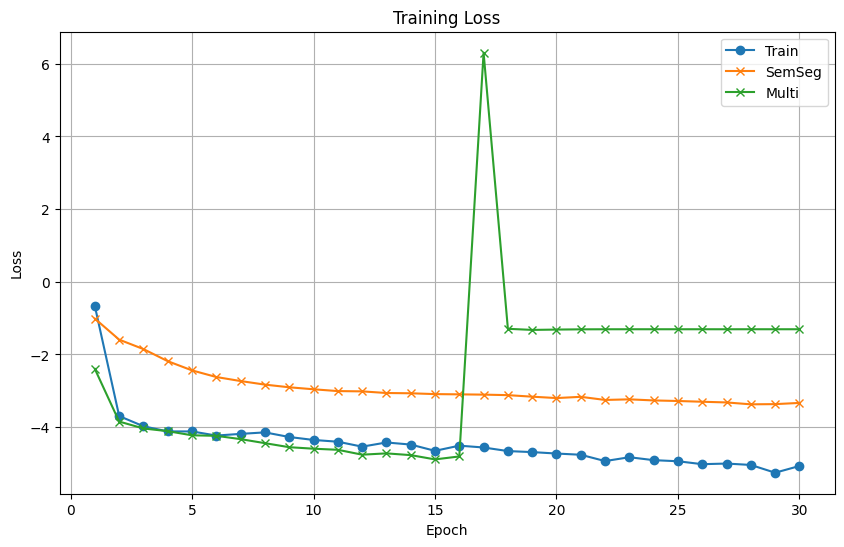

In [5]:

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(epochs_train, np.log(losses_train_rgb), label='Train', marker='o')
plt.plot(epochs_train, np.log(losses_train_semseg), label='SemSeg', marker='x')
plt.plot(epochs_train, np.log(losses_train_multi), label='Multi', marker='x')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.grid(True)
plt.show()

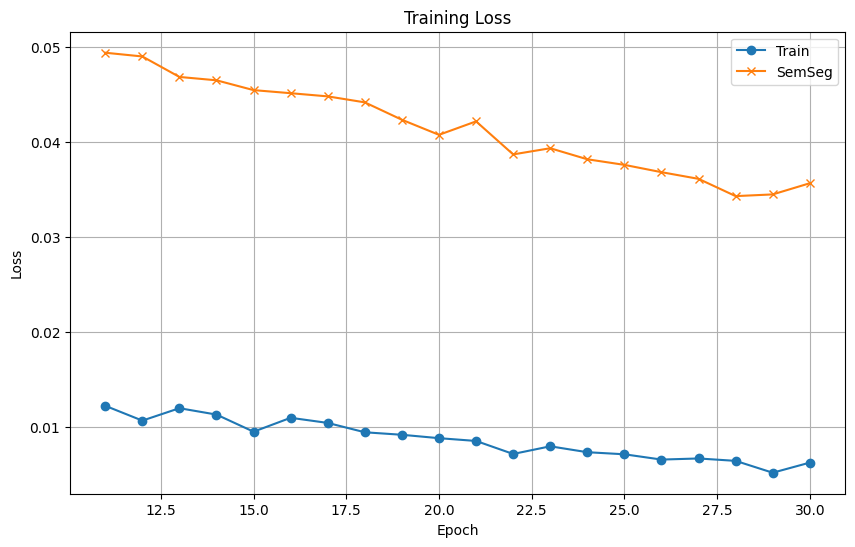

In [10]:

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(epochs_train[10:], losses_train_rgb[10:], label='Train', marker='o')
plt.plot(epochs_train[10:], losses_train_semseg[10:], label='SemSeg', marker='x')
#plt.plot(epochs_train, np.log(losses_train_multi), label='Multi', marker='x')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.grid(True)
plt.show()

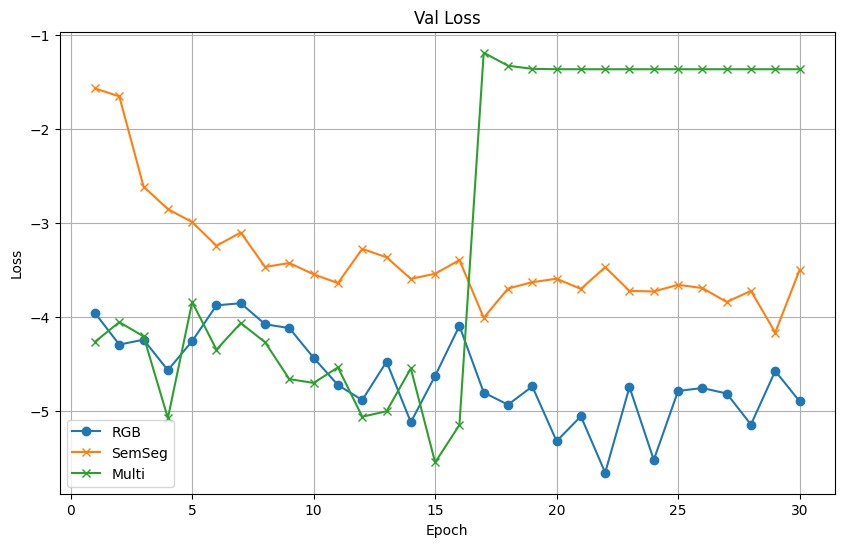

In [11]:

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(epochs_train, np.log(losses_val_rgb), label='RGB', marker='o')
plt.plot(epochs_train, np.log(losses_val_semseg), label='SemSeg', marker='x')
plt.plot(epochs_train, np.log(losses_val_multi), label='Multi', marker='x')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Val Loss')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
losses_val_multi[20:], losses_train_multi[20:]

((0.2549420394003391,
  0.25494165495038035,
  0.25494163781404494,
  0.254941588640213,
  0.25494159013032913,
  0.25494153797626495,
  0.2549432650208473,
  0.2549414739012718,
  0.2549413561820984,
  0.2549417831003666),
 (0.27016105460814943,
  0.27066569313024863,
  0.27077851043297696,
  0.27078800721046253,
  0.2707932295707556,
  0.27081722235068295,
  0.2707016320564808,
  0.2708430162607095,
  0.2707531398687607,
  0.2708076543532885))

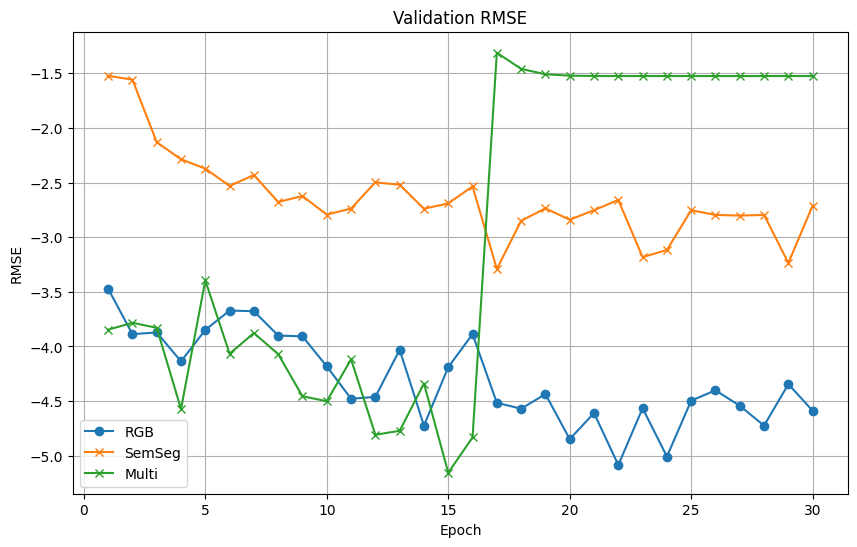

In [7]:

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(epochs_val, np.log(rmse_val_rgb), label='RGB', marker='o')
plt.plot(epochs_val, np.log(rmse_val_semseg), label='SemSeg', marker='x')
plt.plot(epochs_val, np.log(rmse_val_multi), label='Multi', marker='x')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.title('Validation RMSE')
plt.legend()
plt.grid(True)
plt.show()

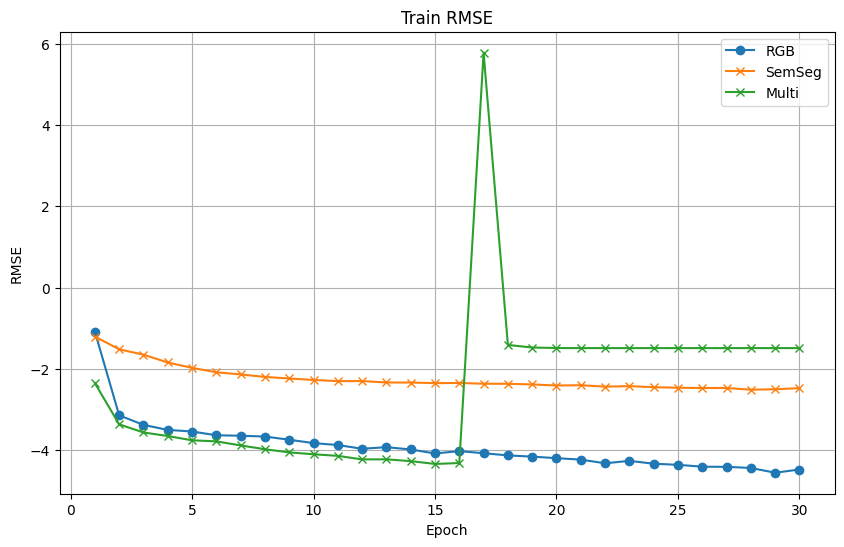

In [8]:

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(epochs_val, np.log(rmse_train_rgb), label='RGB', marker='o')
plt.plot(epochs_val, np.log(rmse_train_semseg), label='SemSeg', marker='x')
plt.plot(epochs_val, np.log(rmse_train_multi), label='Multi', marker='x')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.title('Train RMSE')
plt.legend()
plt.grid(True)
plt.show()

In [23]:
np.min(losses_val_rgb), np.min(losses_val_semseg), np.min(losses_val_multi)

(263.811572265625, 206.81939544677735, 204.46053314208984)